# EDA — Sberbank Russian Housing Market

Разведка данных с использованием пайплайна из `src/`: загрузка train/test/macro, базовая статистика, распределение целевой, пропуски, ключевые признаки.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Корень проекта — для импорта src
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RAW_DIR, TARGET_COL, ID_COL, TIMESTAMP_COL
from src.data import load_and_merge, load_train, load_test, load_macro

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

## 1. Загрузка данных через пайплайн

Используем `load_and_merge()` из `src.data`: train и test объединяются с macro по дате сделки.

In [2]:
train, test = load_and_merge(RAW_DIR, with_macro=True)
print("Train:", train.shape)
print("Test:", test.shape)
print("Колонок в train (с macro):", train.shape[1])

Train: (30471, 391)
Test: (7662, 390)
Колонок в train (с macro): 391


In [3]:
train.head(3)

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,provision_retail_space_modern_sqm,turnover_catering_per_cap,theaters_viewers_per_1000_cap,seats_theather_rfmin_per_100000_cap,museum_visitis_per_100_cap,bandwidth_sports,population_reg_sports_share,students_reg_sports_share,apartment_build,apartment_fund_sqm
0,1,2011-08-20,43,27.0,4.0,NaN,NaN,NaN,NaN,NaN,...,271.0,6943.0,565.0,0.45356,1240.0,269768.0,22.37,64.12,23587.0,230310.0
1,2,2011-08-23,34,19.0,3.0,NaN,NaN,NaN,NaN,NaN,...,271.0,6943.0,565.0,0.45356,1240.0,269768.0,22.37,64.12,23587.0,230310.0
2,3,2011-08-27,43,29.0,2.0,NaN,NaN,NaN,NaN,NaN,...,271.0,6943.0,565.0,0.45356,1240.0,269768.0,22.37,64.12,23587.0,230310.0


## 2. Целевая переменная `price_doc`

Распределение цены и лог-трансформация (часто используется при обучении).

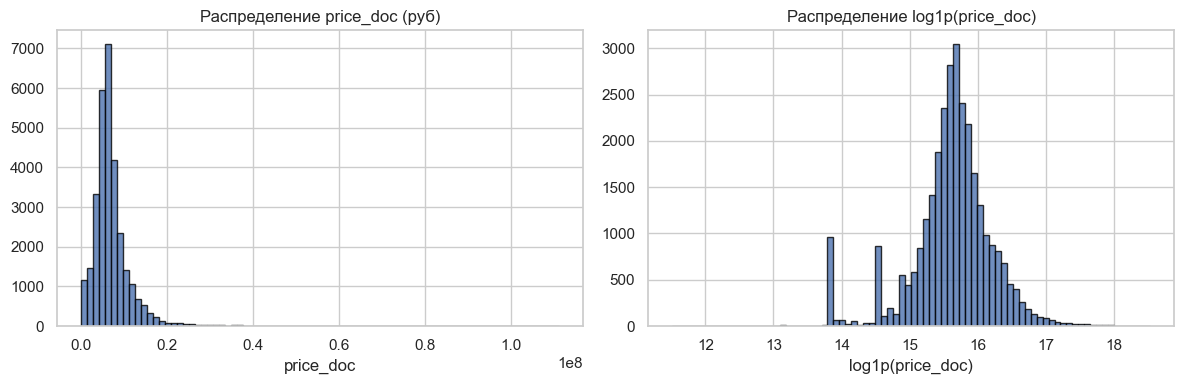

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train[TARGET_COL].hist(bins=80, ax=axes[0], edgecolor="black", alpha=0.8)
axes[0].set_title("Распределение price_doc (руб)")
axes[0].set_xlabel("price_doc")

np.log1p(train[TARGET_COL]).hist(bins=80, ax=axes[1], edgecolor="black", alpha=0.8)
axes[1].set_title("Распределение log1p(price_doc)")
axes[1].set_xlabel("log1p(price_doc)")
plt.tight_layout()
plt.show()

In [5]:
print("Базовая статистика price_doc:")
train[TARGET_COL].describe()

Базовая статистика price_doc:


count    3.047100e+04
mean     7.123035e+06
std      4.780111e+06
min      1.000000e+05
25%      4.740002e+06
50%      6.274411e+06
75%      8.300000e+06
max      1.111111e+08
Name: price_doc, dtype: float64

## 3. Временной диапазон и динамика цен

Даты сделок и медианная цена по времени (месяц).

In [6]:
train[TIMESTAMP_COL] = pd.to_datetime(train[TIMESTAMP_COL])
test[TIMESTAMP_COL] = pd.to_datetime(test[TIMESTAMP_COL])
print("Train: с", train[TIMESTAMP_COL].min(), "по", train[TIMESTAMP_COL].max())
print("Test:  с", test[TIMESTAMP_COL].min(), "по", test[TIMESTAMP_COL].max())

Train: с 2011-08-20 00:00:00 по 2015-06-30 00:00:00
Test:  с 2015-07-01 00:00:00 по 2016-05-30 00:00:00


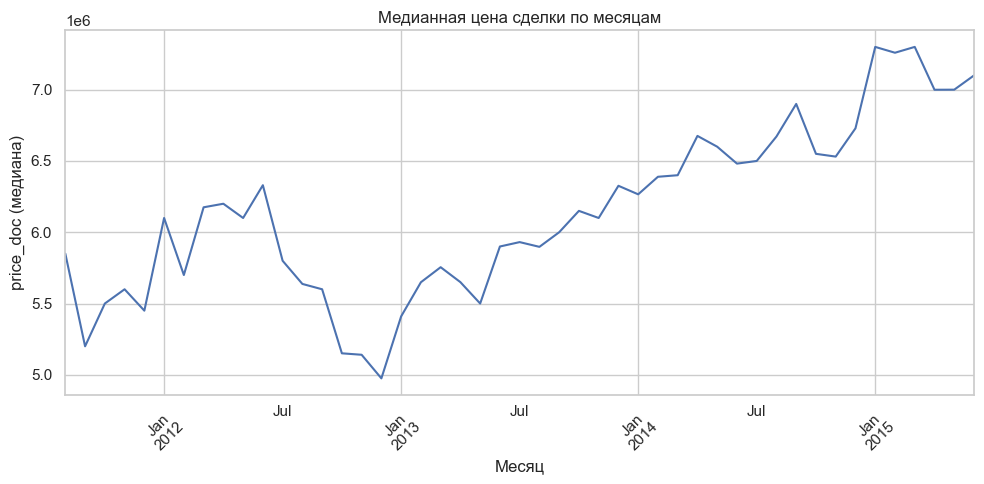

In [7]:
monthly = train.groupby(train[TIMESTAMP_COL].dt.to_period("M"))[TARGET_COL].median()
monthly.plot(title="Медианная цена сделки по месяцам")
plt.xlabel("Месяц")
plt.ylabel("price_doc (медиана)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Пропуски

Доля пропусков по колонкам (топ по пропускам).

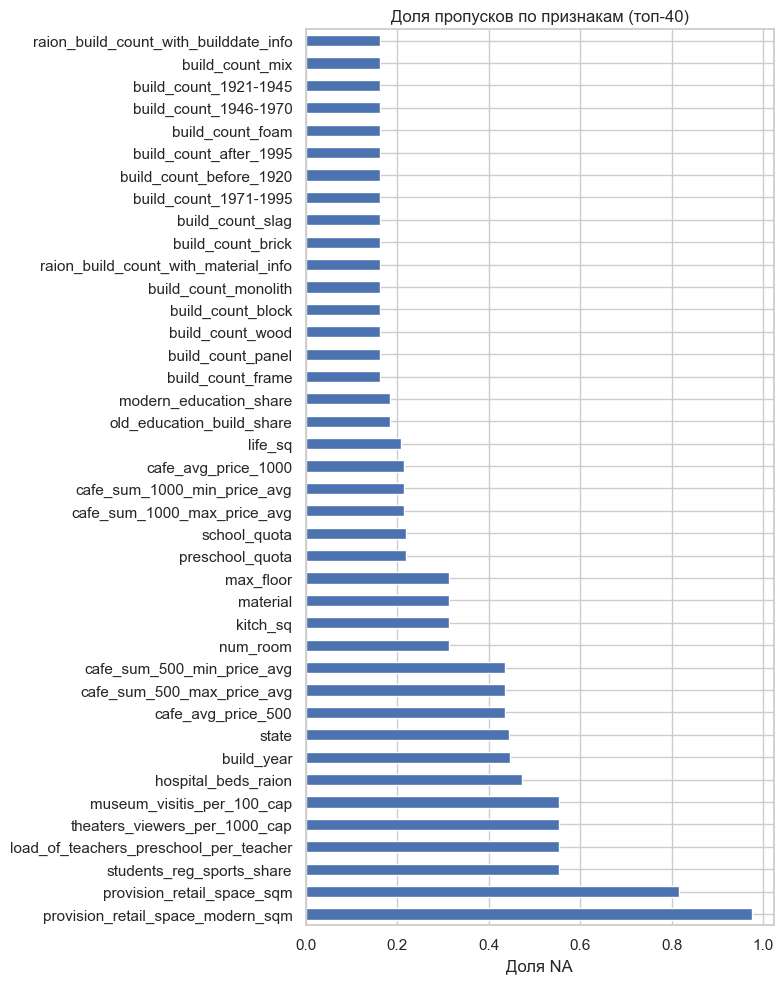

In [8]:
missing = train.isna().mean().sort_values(ascending=False)
missing_top = missing[missing > 0].head(40)
missing_top.plot(kind="barh", figsize=(8, 10))
plt.title("Доля пропусков по признакам (топ-40)")
plt.xlabel("Доля NA")
plt.tight_layout()
plt.show()

In [9]:
print("Колонок с хотя бы одним пропуском:", (missing > 0).sum())
print("Колонок без пропусков:", (missing == 0).sum())

Колонок с хотя бы одним пропуском: 93
Колонок без пропусков: 298


## 5. Ключевые признаки: площадь, этаж, район, тип

Распределения и связь с ценой.

In [10]:
key_cols = ["full_sq", "life_sq", "floor", "num_room", "build_year", "kitch_sq"]
existing = [c for c in key_cols if c in train.columns]
train[existing].describe()

,full_sq,life_sq,floor,num_room,build_year,kitch_sq
count,30471.000000,24088.000000,30304.000000,20899.000000,1.686600e+04,20899.000000
mean,54.214269,34.403271,7.670803,1.909804,3.068057e+03,6.399301
std,38.031487,52.285733,5.319989,0.851805,1.543878e+05,28.265979
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,38.000000,20.000000,3.000000,1.000000,1.967000e+03,1.000000
50%,49.000000,30.000000,6.500000,2.000000,1.979000e+03,6.000000
75%,63.000000,43.000000,11.000000,2.000000,2.005000e+03,9.000000
max,5326.000000,7478.000000,77.000000,19.000000,2.005201e+07,2014.000000


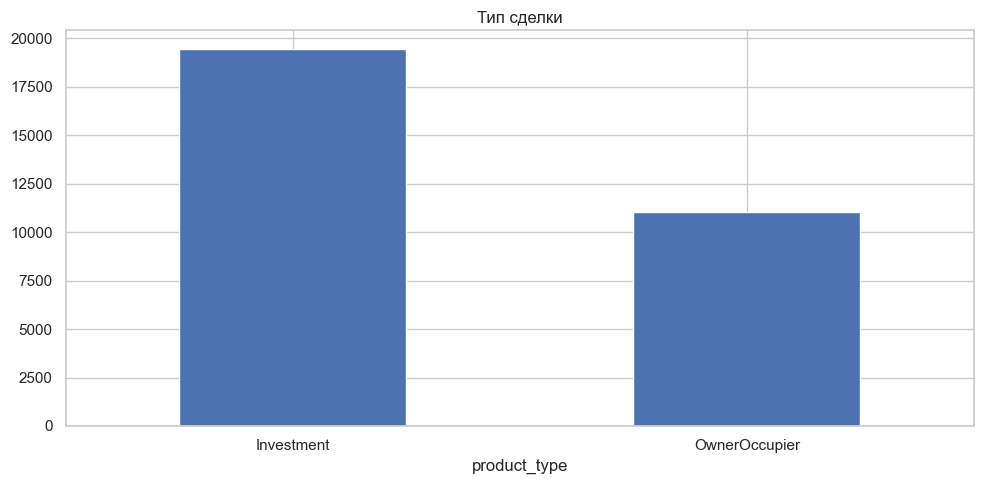

In [11]:
if "product_type" in train.columns:
    train["product_type"].value_counts().plot(kind="bar", title="Тип сделки")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [12]:
if "sub_area" in train.columns:
    areas = train["sub_area"].value_counts()
    print("Число уникальных районов (sub_area):", areas.shape[0])
    print("Топ-15 по количеству сделок:")
    display(areas.head(15))

Число уникальных районов (sub_area): 146
Топ-15 по количеству сделок:


sub_area
Poselenie Sosenskoe         1776
Nekrasovka                  1611
Poselenie Vnukovskoe        1372
Poselenie Moskovskij         925
Poselenie Voskresenskoe      713
Mitino                       679
Tverskoe                     678
Krjukovo                     518
Mar'ino                      508
Poselenie Filimonkovskoe     496
Juzhnoe Butovo               451
Poselenie Shherbinka         443
Solncevo                     421
Zapadnoe Degunino            410
Poselenie Desjonovskoe       362
Name: count, dtype: int64

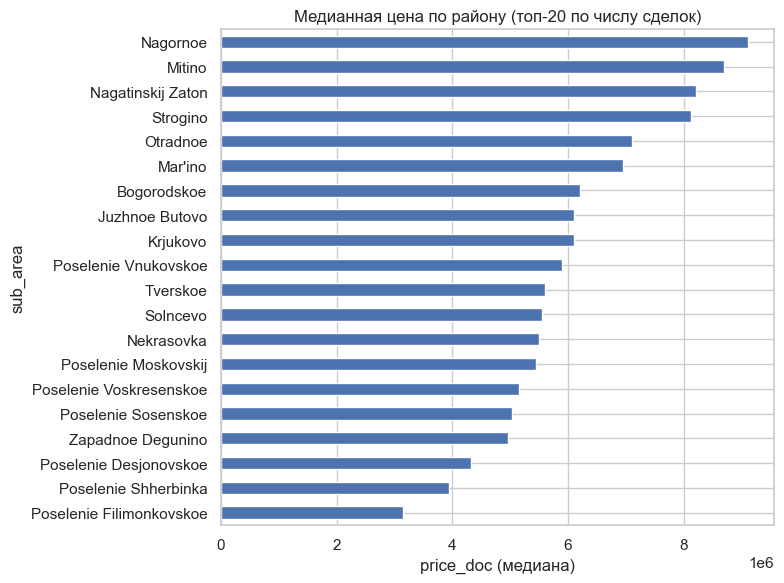

In [13]:
# Медианная цена по району (топ-20 по числу сделок)
if "sub_area" in train.columns:
    top_areas = train["sub_area"].value_counts().head(20).index
    by_area = train[train["sub_area"].isin(top_areas)].groupby("sub_area")[TARGET_COL].median().sort_values(ascending=True)
    by_area.plot(kind="barh", figsize=(8, 6), title="Медианная цена по району (топ-20 по числу сделок)")
    plt.xlabel("price_doc (медиана)")
    plt.tight_layout()
    plt.show()

## 6. Связь числовых признаков с ценой

Корреляции с `price_doc` и с `log1p(price_doc)`; scatter по площади.

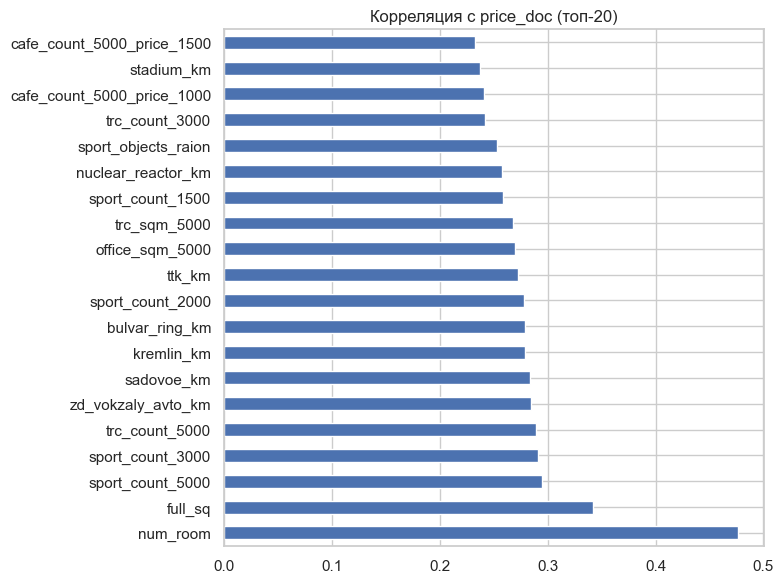

In [14]:
numeric = train.select_dtypes(include=[np.number])
if TARGET_COL in numeric.columns:
    corr_target = numeric.corr()[TARGET_COL].drop(TARGET_COL, errors="ignore").abs().sort_values(ascending=False)
    corr_target.head(20).plot(kind="barh", figsize=(8, 6), title="Корреляция с price_doc (топ-20)")
    plt.tight_layout()
    plt.show()

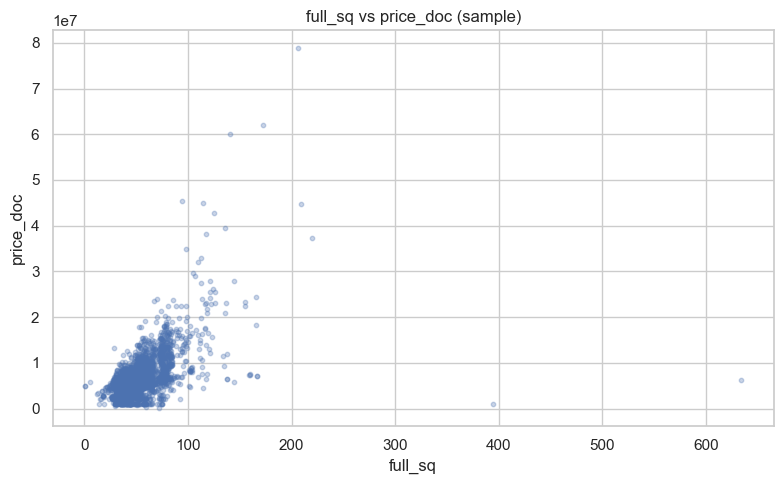

In [15]:
if "full_sq" in train.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sample = train.sample(min(3000, len(train)), random_state=42)
    ax.scatter(sample["full_sq"], sample[TARGET_COL], alpha=0.3, s=10)
    ax.set_xlabel("full_sq")
    ax.set_ylabel("price_doc")
    ax.set_title("full_sq vs price_doc (sample)")
    plt.tight_layout()
    plt.show()

## 7. Подготовка фичей через пайплайн

Используем `prepare_features()` из `src.features`: производные признаки (дата, площади), кодирование, заполнение пропусков. Так мы видим, какие признаки пойдут в модель.

In [16]:
from src.features import prepare_features

X_train, X_test, feature_names = prepare_features(
    train, test,
    add_derived=True,
    fill_na_numeric="median",
    categorical_strategy="ordinal",
    drop_high_missing=0.9,
)
print("Число признаков после подготовки:", len(feature_names))
print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)

Число признаков после подготовки: 394
Размер X_train: (30471, 394)
Размер X_test: (7662, 394)


In [17]:
print("Примеры признаков:", feature_names[:25])

Примеры признаков: ['full_sq', 'life_sq', 'floor', 'max_floor', 'material', 'build_year', 'num_room', 'kitch_sq', 'state', 'area_m', 'raion_popul', 'green_zone_part', 'indust_part', 'children_preschool', 'preschool_quota', 'preschool_education_centers_raion', 'children_school', 'school_quota', 'school_education_centers_raion', 'school_education_centers_top_20_raion', 'hospital_beds_raion', 'healthcare_centers_raion', 'university_top_20_raion', 'sport_objects_raion', 'additional_education_raion']
